# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra import clustering
from astroExplain.spectra import astronomy
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Averages in clusters

In [4]:
def plot_averages_clusters(
    spectra_cluster_dict,
    weights_cluster_dict,
    wave,
):

    n_clusters = len(spectra_cluster_dict)

    fig, axs = plt.subplots(
        nrows=n_clusters,
        ncols=2,
        figsize=None,
        sharex=True,
        sharey=False,
        tight_layout=True,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    #  weights of centroid

    for label, cluster_weights in weights_cluster_dict.items():

        avg_weights = cluster_weights.mean(axis=0)
        avg_weights /= np.max(avg_weights)

        avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

        axs[label, 0].plot(
            wave,
            avg_spectrum,
            color="black",
        )
        # weights
        axs[label, 1].plot(wave, avg_weights, color="black", label=f"Cluster {label}")

        axs[label, 1].legend(
            [f"Cluster {label}"],
            fontsize=6,
            handlelength=0,
            handletextpad=0,
            loc="upper right",
            frameon=False,
        )
        # set limits
        axs[label, 1].set_ylim(0, 1.1)

    axs[n_clusters - 1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[n_clusters - 1, 1].set_xlabel(r"$\lambda$ [nm]")

    return fig, axs

## Top ranked explanations

In [5]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):
        print(f"Explanation for anomaly rank {anomaly_rank + 1}")
        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=None,
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black")
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black", label=f"Cluster {cluster_id}"
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 1)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

# Constants

In [6]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [7]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [9]:
score_name = "mse_filter_250"
bin_id = "bin_03"
n_segments = 343
n_clusters = 7

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_7_clusters_343_segments


## Data

In [10]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [11]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

anomalies_all_dict = {}
specids_all_dict = {}
weights_all_dict = {}

for score_name, run_id in run_ids_dict.items():

    load_from = f"{explanations_dir}/{bin_id}/{score_name}"

    (
        anomalies_arr,
        specobjids_arr,
        weights_dict,
    ) = load_xai(run_id=run_id, load_from=load_from)

    anomalies_all_dict[score_name] = anomalies_arr
    specids_all_dict[score_name] = specobjids_arr
    weights_all_dict[score_name] = weights_prep(
        weights=weights_dict, n_segments=n_segments
    )

# K-means model
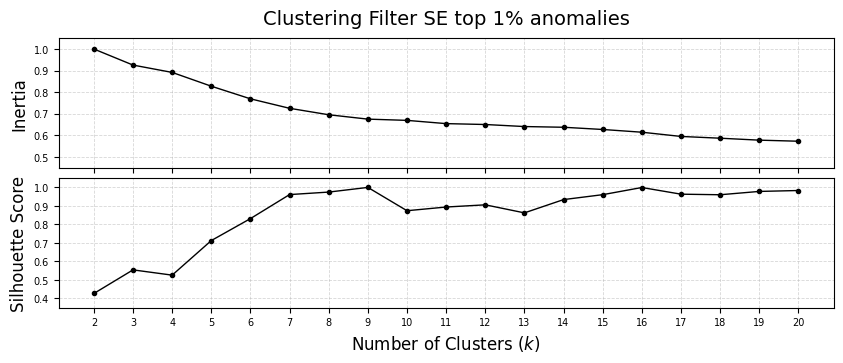

## Train and save

In [ ]:
# ```python
start_time = time.perf_counter()
X = weights_all_dict[score_name]["norm_unique_weights"]
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save the model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# train time: 0.15 seconds
# ['/home/elom/phd/code/clustering/bin_03/mse_filter_250/kmeans_7_clusters_343_segments.joblib']
# ```

train time: 0.15 seconds


['/home/elom/phd/code/clustering/bin_03/mse_filter_250/kmeans_7_clusters_343_segments.joblib']

## Save metadata

In [14]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")

specobjids_array = specids_all_dict[score_name]
cluster_meta_df = meta_with_ratios_df.loc[specobjids_array].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
# ```

# Clusters metadata

In [15]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_all_dict[score_name]["norm_weights"],
    print_n_clusters=True,
)

weights_all_dict[score_name]["spectra_cluster_dict"] = spectra_cluster_dict
weights_all_dict[score_name]["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_all_dict[score_name]["norm_unique_weights"],
    print_n_clusters=False,
)

weights_all_dict[
    score_name
]["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
weights_all_dict[score_name]["centroids"] = centroids

0;173
1;427
2;213
3;237
4;226
5;212
6;331


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
)
cluster_meta_df.shape

(1819, 52)

# Avg Spec & Explanations

In [14]:
for label, centroid in enumerate(xai_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=None,
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

    axs[0].plot(wave_nm, avg_spectrum, color="black", label="Average spectrum")
    axs[0].legend()
    # weights
    axs[1].plot(wave_nm, centroid, color="black", label="Average explanation")
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Top ranked anomalies per cluster

In [23]:
cluster_id = 6

mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = xai_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
)

Number of anomalies in cluster 6: 278
Explanation for anomaly rank 1
Explanation for anomaly rank 2
Explanation for anomaly rank 3
Explanation for anomaly rank 4
Explanation for anomaly rank 5
Explanation for anomaly rank 6
Explanation for anomaly rank 7
Explanation for anomaly rank 8
Explanation for anomaly rank 9
Explanation for anomaly rank 10
Explanation for anomaly rank 11
Explanation for anomaly rank 12
Explanation for anomaly rank 13
Explanation for anomaly rank 14
Explanation for anomaly rank 15
Explanation for anomaly rank 16
Explanation for anomaly rank 17
Explanation for anomaly rank 18
Explanation for anomaly rank 19
Explanation for anomaly rank 20
Explanation for anomaly rank 21


# Line ratios

In [17]:
cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].describe()

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,sii_to_halpha,sii_density_ratio,o3n2_index
count,1785.000000,1780.000000,1779.000000,1.319000e+03,1.702000e+03,1.706000e+03,1758.000000
mean,83.393615,0.355319,3.256051,2.400250e+00,8.601629e+04,1.391459e+00,0.848145
std,3334.929230,0.776495,21.853361,8.136999e+00,3.548616e+06,1.208053e+00,0.698301
min,0.036110,0.000004,0.048726,1.103384e-08,7.499223e-06,8.169128e-10,-1.176081
25%,3.273033,0.112121,0.788741,8.250245e-01,2.028204e-01,1.249673e+00,0.272622
50%,3.593491,0.205114,1.955763,1.500842e+00,2.424836e-01,1.349633e+00,0.981677
75%,4.272312,0.423180,3.019296,2.365022e+00,2.851698e-01,1.405228e+00,1.374862
max,140901.290334,22.009314,816.104492,2.589991e+02,1.463992e+08,3.274728e+01,5.525173


In [18]:
n_nans = cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].isna().sum()
n_negatives = (cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES] < 0).sum()
n_zeros = (cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_nans,n_negatives,n_zeros
0,balmer_decrement,34,0,0
1,nii_to_halpha,39,0,0
2,oiii_to_hbeta,40,0,0
3,oiii_to_oii,500,0,0
4,sii_to_halpha,117,0,0
5,sii_density_ratio,113,0,0
6,o3n2_index,61,268,0


In [19]:
# Compute deciles (10th to 90th percentiles) for each column
deciles = np.arange(0.01, 1.01, 0.01)
decile_df = cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df

,1th,2th,3th,4th,5th,6th,6th,8th,9th,10th,...,91th,92th,93th,94th,95th,96th,97th,98th,99th,100th
balmer_decrement,0.761443,1.396572,2.267891,2.597411,2.784606,2.874947,2.940567,2.986052,3.015926,3.030953,...,5.381568,5.479523,5.592642,5.778534,5.982662,6.284399,6.791955,7.812836,9.772244,1.409013e+05
nii_to_halpha,0.035917,0.045465,0.050183,0.055812,0.059553,0.063127,0.066419,0.068153,0.070786,0.073714,...,0.715886,0.746652,0.794060,0.860733,0.924339,1.003661,1.118077,1.236932,1.604067,2.200931e+01
oiii_to_hbeta,0.123876,0.158732,0.178183,0.197269,0.218281,0.231925,0.250025,0.269495,0.286347,0.308365,...,4.571363,4.764244,5.308956,6.148219,7.141368,8.260116,9.404119,10.365991,11.383026,8.161045e+02
oiii_to_oii,0.002204,0.052045,0.269462,0.377762,0.410421,0.433868,0.462420,0.480223,0.501064,0.520477,...,4.670079,4.985211,5.431179,6.006646,6.855124,7.471605,8.493451,9.739948,11.924187,2.589991e+02
sii_to_halpha,0.106471,0.126754,0.133696,0.140573,0.144718,0.148774,0.151767,0.156351,0.161204,0.165177,...,0.402824,0.425141,0.454859,0.484721,0.528705,0.570332,0.646192,0.763625,0.986321,1.463992e+08
sii_density_ratio,0.820071,0.940178,0.977285,0.999977,1.020391,1.048925,1.066143,1.076366,1.089986,1.106263,...,1.468021,1.474328,1.483285,1.493447,1.511712,1.542929,1.590977,1.763392,2.973673,3.274728e+01
o3n2_index,-0.559088,-0.483887,-0.431713,-0.371521,-0.328377,-0.287098,-0.240044,-0.213464,-0.183050,-0.150719,...,1.679498,1.715669,1.748099,1.771853,1.807353,1.854637,1.904533,1.979536,2.112627,5.525173e+00


# Median line ratios

In [20]:
n_clusters = len(cluster_meta_df["cluster"].unique())
df, ratio_cols = astronomy.compute_emission_line_ratios(cluster_meta_df)
range_n_clusters = range(0, n_clusters)

median_cluster_ratios_df = pd.DataFrame(
    index=range_n_clusters,
    columns=ratio_cols,
)
for cluster_id in range_n_clusters:

    mask = df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,o3n2 index,sii to halpha,sii density ratio
0,3.517211,0.154253,2.125665,1.584673,1.097328,0.237366,1.374522
1,4.636111,0.412727,0.556371,0.824707,0.099248,0.253382,1.24981
2,3.45454,0.167534,1.85812,1.405085,1.023005,0.244916,1.374398
3,3.296409,0.567146,1.646857,1.164706,0.366259,0.391847,1.416549
4,3.702079,0.246344,0.923697,0.59686,0.534174,0.2446,1.367
5,3.377601,0.12105,2.771459,2.190532,1.340624,0.211798,1.364336
6,3.362388,0.105819,3.542437,2.726517,1.42715,0.21718,1.367817


In [44]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = df[SDSS_NEBULAR_LINES_RATIOS_NAMES].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer decrement,3.603107,3.620602,3.632930,3.647116,3.668969,3.679038,3.692443,3.709852,3.723891,3.741098,3.755085
nii to halpha,0.234838,0.239975,0.245432,0.250207,0.254902,0.259614,0.268189,0.277796,0.285090,0.290669,0.298330
oiii to hbeta,1.546710,1.601287,1.639899,1.694527,1.730276,1.772498,1.815691,1.847271,1.879173,1.925877,1.985341
oiii to oii,1.287236,1.312636,1.345774,1.372980,1.412035,1.458075,1.483448,1.509572,1.528156,1.544221,1.586794
sii to halpha,0.259456,0.261544,0.264104,0.266410,0.267988,0.269740,0.271213,0.273678,0.275551,0.277863,0.278859
sii density ratio,1.334871,1.336922,1.340285,1.344557,1.347186,1.349667,1.352247,1.355150,1.357635,1.359672,1.362148
o3n2 index,0.752555,0.765060,0.782803,0.798406,0.814355,0.837632,0.853038,0.866577,0.878822,0.891983,0.909533


## Cluster 0 ratios percentiles

In [34]:
cluster_mask = df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.388351,3.492172,3.666359,3.806720,3.877908
nii_to_halpha,0.336484,0.368795,0.397809,0.439324,0.507358
oiii_to_hbeta,0.860697,1.001380,1.147750,1.385974,1.613586
oiii_to_oii,0.822200,0.931579,1.012432,1.093690,1.274567
sii_to_halpha,0.304698,0.317194,0.331171,0.344981,0.365690
sii_density_ratio,1.339225,1.361376,1.380323,1.393937,1.411739
o3n2_index,0.219461,0.322873,0.422605,0.528161,0.638322


## Cluster 1 ratios percentiles

In [35]:
cluster_mask = df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.271607,3.318220,3.349590,3.388522,3.421027
nii_to_halpha,0.125872,0.140536,0.148788,0.159554,0.172783
oiii_to_hbeta,1.626892,1.738940,1.854047,2.021417,2.172681
oiii_to_oii,1.159342,1.279306,1.392964,1.493772,1.534688
sii_to_halpha,0.240258,0.251432,0.262177,0.270817,0.278798
sii_density_ratio,1.371625,1.379711,1.389906,1.398789,1.407852
o3n2_index,0.967396,1.033659,1.094535,1.171554,1.227462


## Cluster 2 percentiles

In [36]:
cluster_mask = df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.613526,3.681800,3.753831,3.848693,3.930665
nii_to_halpha,0.182155,0.206746,0.231533,0.251248,0.275398
oiii_to_hbeta,1.235564,1.386177,1.547845,1.726729,1.917577
oiii_to_oii,1.172694,1.260825,1.357094,1.512118,1.606773
sii_to_halpha,0.222758,0.230608,0.242563,0.253764,0.261612
sii_density_ratio,1.322090,1.337748,1.349610,1.360427,1.372144
o3n2_index,0.615994,0.682301,0.791194,0.891084,0.992396


## Cluster 3 ratios percentiles

In [37]:
cluster_mask = df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.878251,3.958174,4.030006,4.129196,4.240777
nii_to_halpha,0.350484,0.364034,0.386647,0.405449,0.453664
oiii_to_hbeta,0.856108,0.966327,1.084887,1.245762,1.361614
oiii_to_oii,0.861857,0.949365,1.081261,1.225648,1.398189
sii_to_halpha,0.260327,0.268433,0.275126,0.282457,0.289825
sii_density_ratio,1.243400,1.262293,1.273602,1.295795,1.311048
o3n2_index,0.328095,0.389613,0.445649,0.523375,0.573572


## Cluster 4 ratios percentiles

In [38]:
cluster_mask = df["cluster"] == 4
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.405688,3.461054,3.506932,3.549910,3.645915
nii_to_halpha,0.111060,0.123408,0.150961,0.215052,0.324118
oiii_to_hbeta,3.486602,3.686493,3.900146,4.110182,4.396615
oiii_to_oii,3.281362,3.728288,4.107858,4.721793,4.992927
sii_to_halpha,0.209379,0.222928,0.243405,0.263142,0.289531
sii_density_ratio,1.295411,1.314385,1.332415,1.351169,1.361864
o3n2_index,1.183794,1.236093,1.288792,1.376029,1.429653


## Cluster 5 percentiles

In [39]:
cluster_mask = df["cluster"] == 5
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.977677,4.029206,4.157823,4.177023,4.230869
nii_to_halpha,0.447359,0.529368,0.592740,0.622559,0.647434
oiii_to_hbeta,2.478656,2.798481,2.953400,3.665737,3.979601
oiii_to_oii,2.830475,3.493484,4.136077,4.294528,4.842914
sii_to_halpha,0.298179,0.306548,0.312370,0.340625,0.363934
sii_density_ratio,1.234801,1.257313,1.272204,1.293169,1.306468
o3n2_index,0.747841,0.784590,0.802257,0.844069,0.862862


# Redshift Analysis

In [40]:
n_clusters = len(cluster_meta_df["cluster"].unique())
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010673,0.262315,0.086829,0.084388
1,1,0.011578,0.179591,0.041957,0.027449
2,2,0.010144,0.261698,0.066204,0.052359
3,3,0.010093,0.271920,0.080271,0.070965
4,4,0.010132,0.234167,0.056268,0.041165
5,5,0.115890,0.121675,0.118367,0.118102


In [41]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010673,0.262315,0.086829,0.084388,5506.234165,5530.970168,4408.565054,4428.369928,5120.400772,5143.403471,5131.927801,5154.982283
1,1,0.011578,0.179591,0.041957,0.027449,5501.307240,5526.021109,4717.738510,4738.932304,5340.909002,5364.902304,5416.325178,5440.657277
2,2,0.010144,0.261698,0.066204,0.052359,5509.114550,5533.863493,4410.724441,4430.539016,5219.451571,5242.899242,5288.116871,5311.873012
3,3,0.010093,0.271920,0.080271,0.070965,5509.396417,5534.146625,4375.274831,4394.930153,5151.482875,5174.625206,5196.249020,5219.592456
4,4,0.010132,0.234167,0.056268,0.041165,5509.182778,5533.932027,4509.113149,4529.369722,5268.549182,5292.217417,5344.972959,5368.984517
5,5,0.115890,0.121675,0.118367,0.118102,4987.051142,5009.454786,4961.332365,4983.620471,4976.006903,4998.360932,4977.182325,4999.541634
